In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("javierbarrnun/saudi-electricity-data-grouped-at-1-hour-avg")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'saudi-electricity-data-grouped-at-1-hour-avg' dataset.
Path to dataset files: /kaggle/input/saudi-electricity-data-grouped-at-1-hour-avg


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_PATH = "/kaggle/input/saudi-electricity-data-grouped-at-1-hour-avg"

os.listdir(DATA_PATH)

['dec_11_groupedAt1h.csv']

**DATA LOADING**

In [25]:
df = pd.read_csv(os.path.join(DATA_PATH, os.listdir(DATA_PATH)[0]))

df.head()

,Unnamed: 0,MeterID,ReadingTime,ReadingValue_mean,ReadingValue_std,ReadingValue_count,ReadingValue_sum,PrevHourAVG_mean,PrevHourAVG_std,PrevHourAVG_count,PrevHourAVG_sum,PrevHourDelta_mean,PrevHourDelta_std,PrevHourDelta_count,PrevHourDelta_sum,TimeOfDay
0,0,AEC2020830063612,2023-12-11 00:00:00+03:00,95.685750,163.712916,56,5358.402,95.948500,161.787872,56,5373.116,-0.262750,139.181423,56,-14.714,evening
1,1,AEC2020830063612,2023-12-11 01:00:00+03:00,89.405600,160.167516,60,5364.336,89.373367,159.850372,60,5362.402,0.032233,1.350576,60,1.934,evening
2,2,AEC2020830063612,2023-12-11 02:00:00+03:00,89.613667,160.488585,60,5376.820,89.405600,160.167516,60,5364.336,0.208067,0.536491,60,12.484,evening
3,3,AEC2020830063612,2023-12-11 03:00:00+03:00,89.796583,160.858169,60,5387.795,89.613667,160.488585,60,5376.820,0.182917,0.558546,60,10.975,evening
4,4,AEC2020830063612,2023-12-11 04:00:00+03:00,89.936283,161.192203,60,5396.177,89.796583,160.858169,60,5387.795,0.139700,0.573971,60,8.382,evening


**DATA SUMMARY**

In [26]:
print("Shape:", df.shape)

Shape: (45654, 16)


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45654 entries, 0 to 45653
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           45654 non-null  int64  
 1   MeterID              45654 non-null  object 
 2   ReadingTime          45654 non-null  object 
 3   ReadingValue_mean    45541 non-null  float64
 4   ReadingValue_std     45541 non-null  float64
 5   ReadingValue_count   45654 non-null  int64  
 6   ReadingValue_sum     45654 non-null  float64
 7   PrevHourAVG_mean     45541 non-null  float64
 8   PrevHourAVG_std      45541 non-null  float64
 9   PrevHourAVG_count    45654 non-null  int64  
 10  PrevHourAVG_sum      45654 non-null  float64
 11  PrevHourDelta_mean   45541 non-null  float64
 12  PrevHourDelta_std    45541 non-null  float64
 13  PrevHourDelta_count  45654 non-null  int64  
 14  PrevHourDelta_sum    45654 non-null  float64
 15  TimeOfDay            45654 non-null 

**STATISTICAL DESCRIPTION**

In [28]:
df.describe()

,Unnamed: 0,ReadingValue_mean,ReadingValue_std,ReadingValue_count,ReadingValue_sum,PrevHourAVG_mean,PrevHourAVG_std,PrevHourAVG_count,PrevHourAVG_sum,PrevHourDelta_mean,PrevHourDelta_std,PrevHourDelta_count,PrevHourDelta_sum
count,45654.000000,45541.000000,45541.000000,45654.000000,45654.000000,45541.000000,45541.000000,45654.000000,45654.000000,45541.000000,45541.000000,45654.000000,45654.000000
mean,22826.500000,38.172827,71.283845,59.568055,2273.792029,38.165000,71.294410,59.568055,2273.160823,0.007827,5.800596,59.568055,0.631205
std,13179.318932,12.801344,22.852893,3.659871,774.909829,12.799896,22.843954,3.659871,774.877637,1.252455,15.019465,3.659871,72.319226
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-30.512333,0.000000,0.000000,-1636.879000
25%,11413.250000,29.228650,53.136029,60.000000,1744.870000,29.224383,53.144853,60.000000,1744.351000,-0.197433,0.470901,60.000000,-11.734750
50%,22826.500000,33.444950,57.447140,60.000000,1993.339000,33.404267,57.449913,60.000000,1992.190500,0.016050,1.439656,60.000000,0.909000
75%,34239.750000,47.925433,92.560303,60.000000,2868.716250,47.925433,92.573634,60.000000,2868.397000,0.192033,3.978359,60.000000,11.429000
max,45653.000000,122.187400,207.127639,60.000000,7331.244000,122.187400,207.127639,60.000000,7331.244000,28.835964,203.964867,60.000000,1614.814000


In [29]:
print(df.columns)

Index(['Unnamed: 0', 'MeterID', 'ReadingTime', 'ReadingValue_mean',
       'ReadingValue_std', 'ReadingValue_count', 'ReadingValue_sum',
       'PrevHourAVG_mean', 'PrevHourAVG_std', 'PrevHourAVG_count',
       'PrevHourAVG_sum', 'PrevHourDelta_mean', 'PrevHourDelta_std',
       'PrevHourDelta_count', 'PrevHourDelta_sum', 'TimeOfDay'],
      dtype='object')


**FEATURE EXTRACTION**

In [30]:
# Electricity demand varies significantly across hours.
df['ReadingTime'] = pd.to_datetime(df['ReadingTime'])
df['hour'] = df['ReadingTime'].dt.hour

In [31]:
# Momentum (current load change compared to previous hour)
df["momentum"] = df["ReadingValue_mean"] - df["PrevHourAVG_mean"]

In [32]:
# Measures the relative change of the current load
df["load_ratio"] = df["ReadingValue_mean"] / (df["PrevHourAVG_mean"] + 1e-6)


In [33]:
# Measures stability of the load during the current hour.
# High volatility -> unstable consumption
# Low volatility -> stable load
df["volatility"] = df["ReadingValue_std"] / (df["ReadingValue_mean"] + 1e-6)


In [34]:
# Measures how strong the load change is relative
# to its natural variability.

df["normalized_delta"] = (
    (df["ReadingValue_mean"] - df["PrevHourAVG_mean"])
    / (df["ReadingValue_std"] + 1e-6)
)

**TARGET LABEL**

In [35]:
# Make sure ReadingTime is datetime and data is ordered correctly
df["ReadingTime"] = pd.to_datetime(df["ReadingTime"])
df = df.sort_values(["MeterID", "ReadingTime"]).reset_index(drop=True)

# Create next-hour value for each meter separately
df["target_next_hour"] = df.groupby("MeterID")["ReadingValue_mean"].shift(-1)

# Create binary target label
df["target"] = (df["target_next_hour"] > df["ReadingValue_mean"]).astype(int)

# Drop rows where next hour does not exist
df = df.dropna(subset=["target_next_hour"]).copy()

**REMOVING FEATURES**

In [36]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [37]:
df = df.drop(columns=["target_next_hour"])

**CHEACKING MISSING VALUES**

In [38]:
missing_table = pd.DataFrame({
    "Feature": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum()/len(df))*100
})

missing_table.sort_values("Missing_Count", ascending=False)

,Feature,Missing_Count,Missing_Percentage
ReadingValue_mean,ReadingValue_mean,27,0.061911
ReadingValue_std,ReadingValue_std,27,0.061911
PrevHourDelta_std,PrevHourDelta_std,27,0.061911
PrevHourAVG_std,PrevHourAVG_std,27,0.061911
PrevHourAVG_mean,PrevHourAVG_mean,27,0.061911
load_ratio,load_ratio,27,0.061911
volatility,volatility,27,0.061911
normalized_delta,normalized_delta,27,0.061911
PrevHourDelta_mean,PrevHourDelta_mean,27,0.061911
momentum,momentum,27,0.061911


/tmp/ipykernel_3312/182190783.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


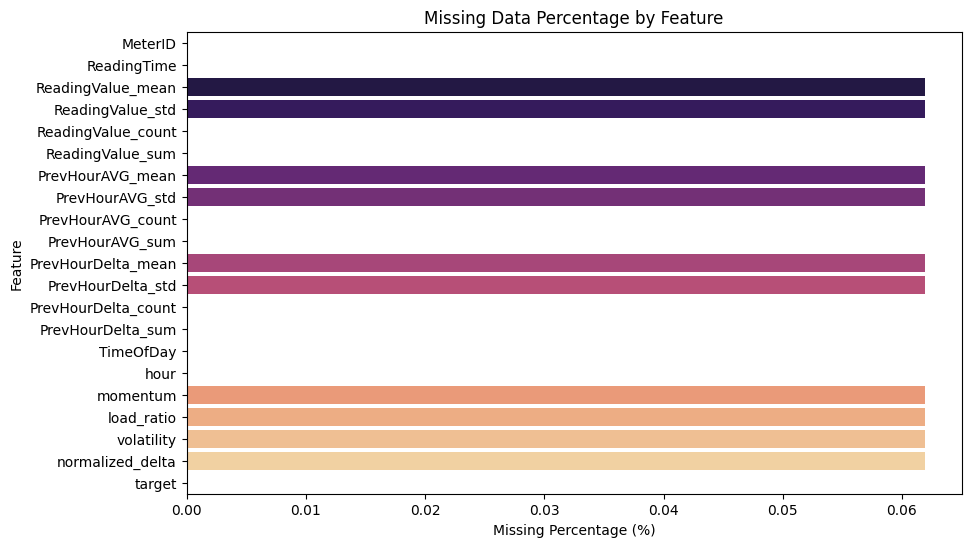

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Missing_Percentage",
    y="Feature",
    data=missing_table,
    palette="magma"
)

plt.title("Missing Data Percentage by Feature")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")

plt.show()

**HANDLING MISSING VALUES (DRPPING BECAUSE MISSING RATE IS VERY SMALL)**

In [40]:
df = df.dropna().copy()


**AFTER HANDLING MISSING VALUES**

In [41]:
missing_table = pd.DataFrame({
    "Feature": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum()/len(df))*100
})

missing_table.sort_values("Missing_Count", ascending=False)

,Feature,Missing_Count,Missing_Percentage
MeterID,MeterID,0,0.0
ReadingTime,ReadingTime,0,0.0
ReadingValue_mean,ReadingValue_mean,0,0.0
ReadingValue_std,ReadingValue_std,0,0.0
ReadingValue_count,ReadingValue_count,0,0.0
ReadingValue_sum,ReadingValue_sum,0,0.0
PrevHourAVG_mean,PrevHourAVG_mean,0,0.0
PrevHourAVG_std,PrevHourAVG_std,0,0.0
PrevHourAVG_count,PrevHourAVG_count,0,0.0
PrevHourAVG_sum,PrevHourAVG_sum,0,0.0


**DUPLICATE ROWS DETECTION**

In [42]:
df.duplicated().sum()

np.int64(0)

Correlation Analysis

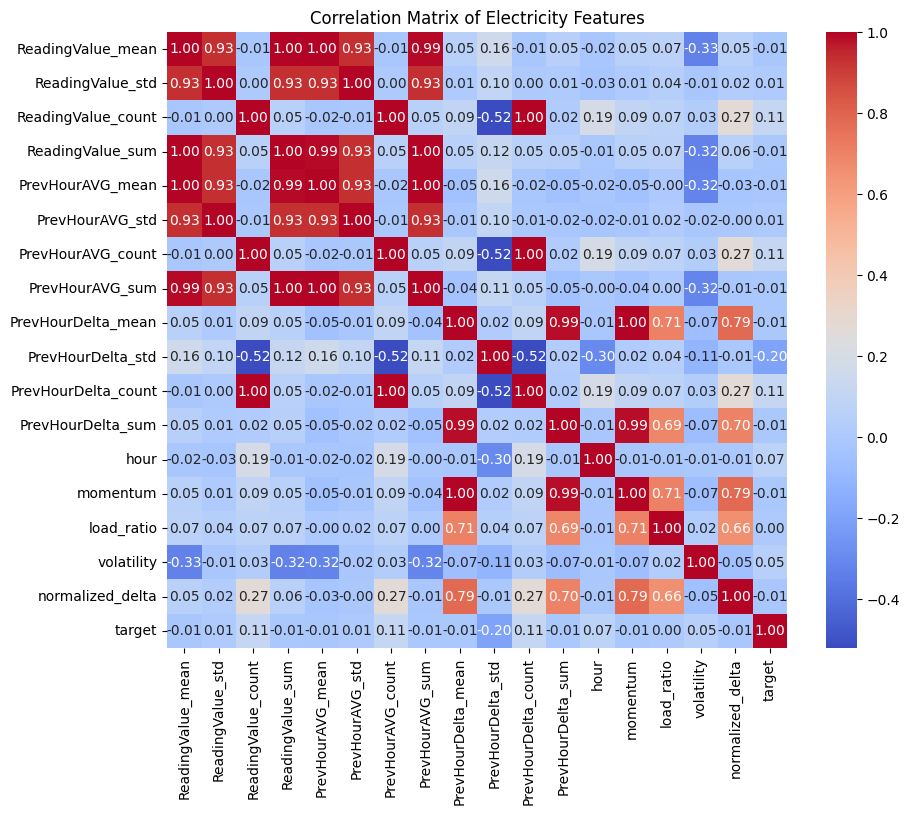

In [43]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Electricity Features")
plt.show()

In [44]:
df.to_csv("/content/cleaned_dataset2.csv", index=False)

**BASED ON THE ANALYSIS ACTIONS**

TIME OF DAY IS NOT INFORMATIVE

In [45]:
df = df.drop(columns=["TimeOfDay"])

**IMBALANCE VISUALISATION**

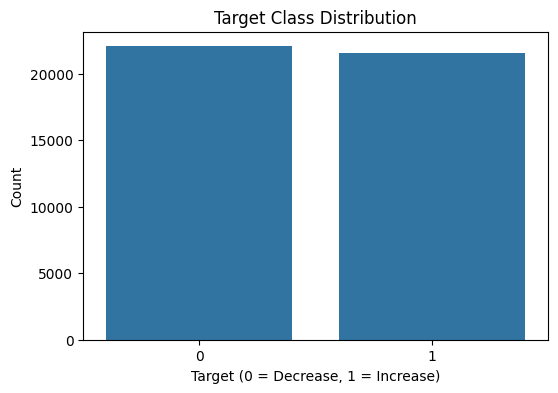

target
0    0.506034
1    0.493966
Name: proportion, dtype: float64


In [46]:
plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Target Class Distribution")
plt.xlabel("Target (0 = Decrease, 1 = Increase)")
plt.ylabel("Count")

plt.show()

print(df["target"].value_counts(normalize=True))

**DETECT OUTLIER**

In [47]:
# ------------------------------------------------
# Select numerical columns for outlier analysis
# ------------------------------------------------

numeric_features = [
    "ReadingValue_mean",
    "ReadingValue_std",
    "ReadingValue_sum",
    "PrevHourAVG_mean",
    "PrevHourAVG_std",
    "PrevHourAVG_sum",
    "PrevHourDelta_mean",
    "PrevHourDelta_std",
    "PrevHourDelta_sum",
    "momentum",
    "volatility",
    "load_ratio",
    "normalized_delta"
]

print("Features used for outlier analysis:")
print(numeric_features)

Features used for outlier analysis:
['ReadingValue_mean', 'ReadingValue_std', 'ReadingValue_sum', 'PrevHourAVG_mean', 'PrevHourAVG_std', 'PrevHourAVG_sum', 'PrevHourDelta_mean', 'PrevHourDelta_std', 'PrevHourDelta_sum', 'momentum', 'volatility', 'load_ratio', 'normalized_delta']


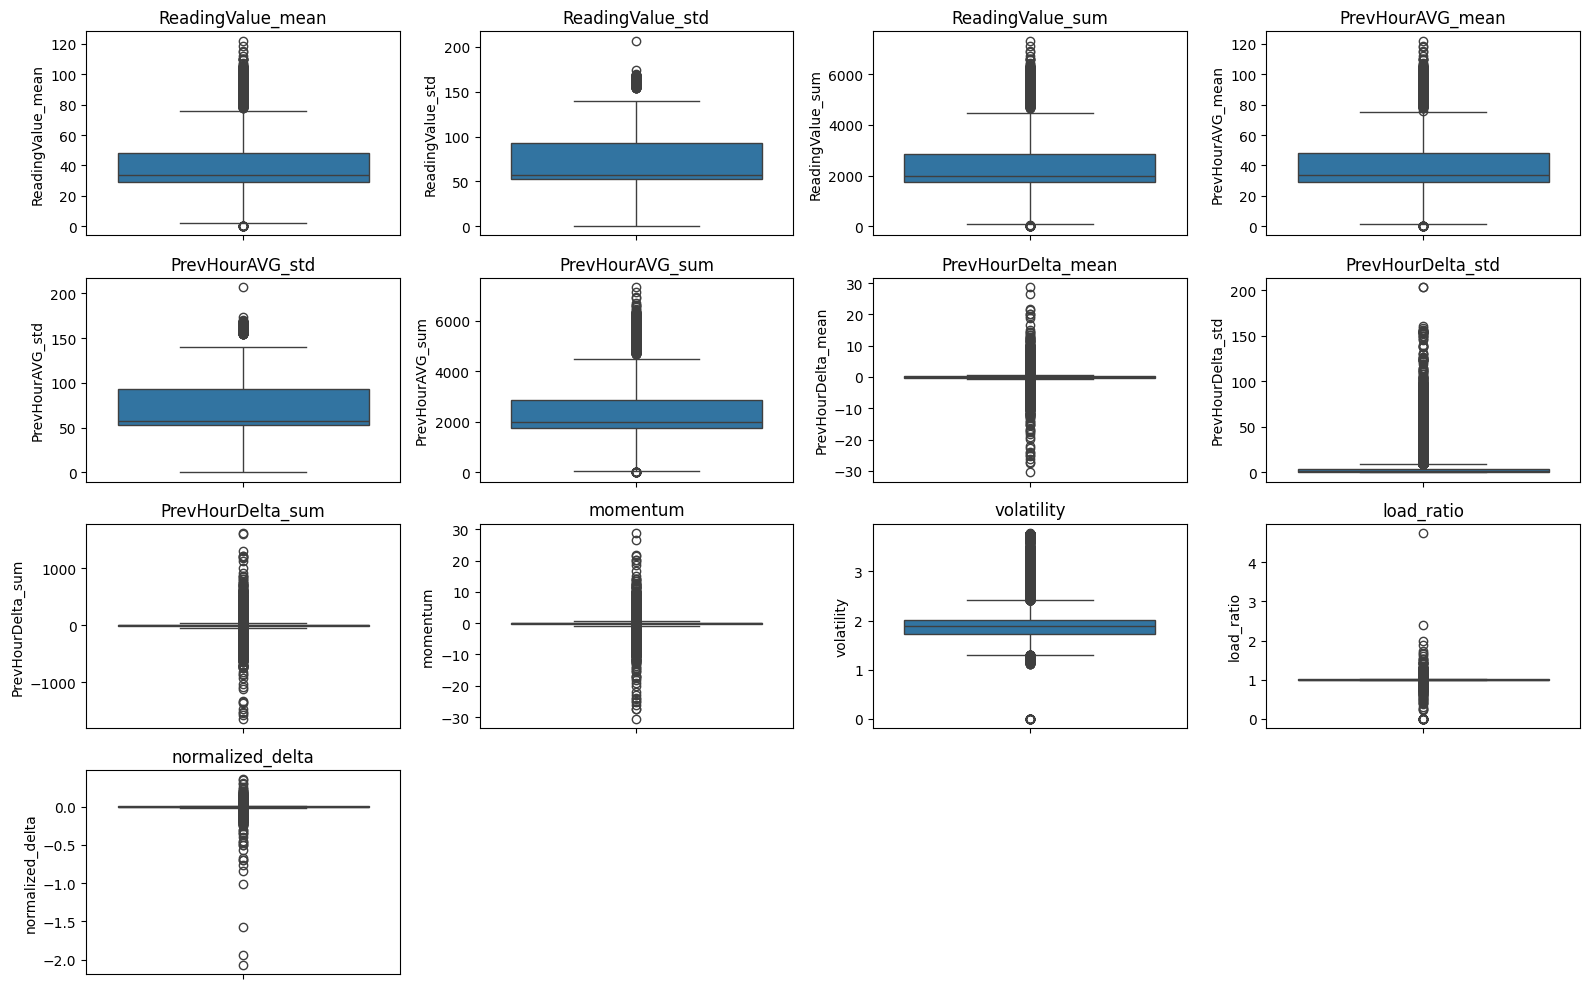

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))

for i, col in enumerate(numeric_features, 1):

    plt.subplot(4,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [49]:
# ---------------------------------------------------
# Handle outliers using IQR clipping (Winsorization)
# ---------------------------------------------------

df_clean = df.copy()

outlier_features = [
    "ReadingValue_mean",
    "ReadingValue_std",
    "ReadingValue_sum",
    "PrevHourAVG_mean",
    "PrevHourAVG_std",
    "PrevHourAVG_sum",
    "PrevHourDelta_mean",
    "PrevHourDelta_std",
    "PrevHourDelta_sum",
    "momentum",
    "volatility",
    "load_ratio",
    "normalized_delta"
]

for col in outlier_features:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[col] = df_clean[col].clip(lower, upper)

print("Outlier handling completed using IQR clipping.")

Outlier handling completed using IQR clipping.


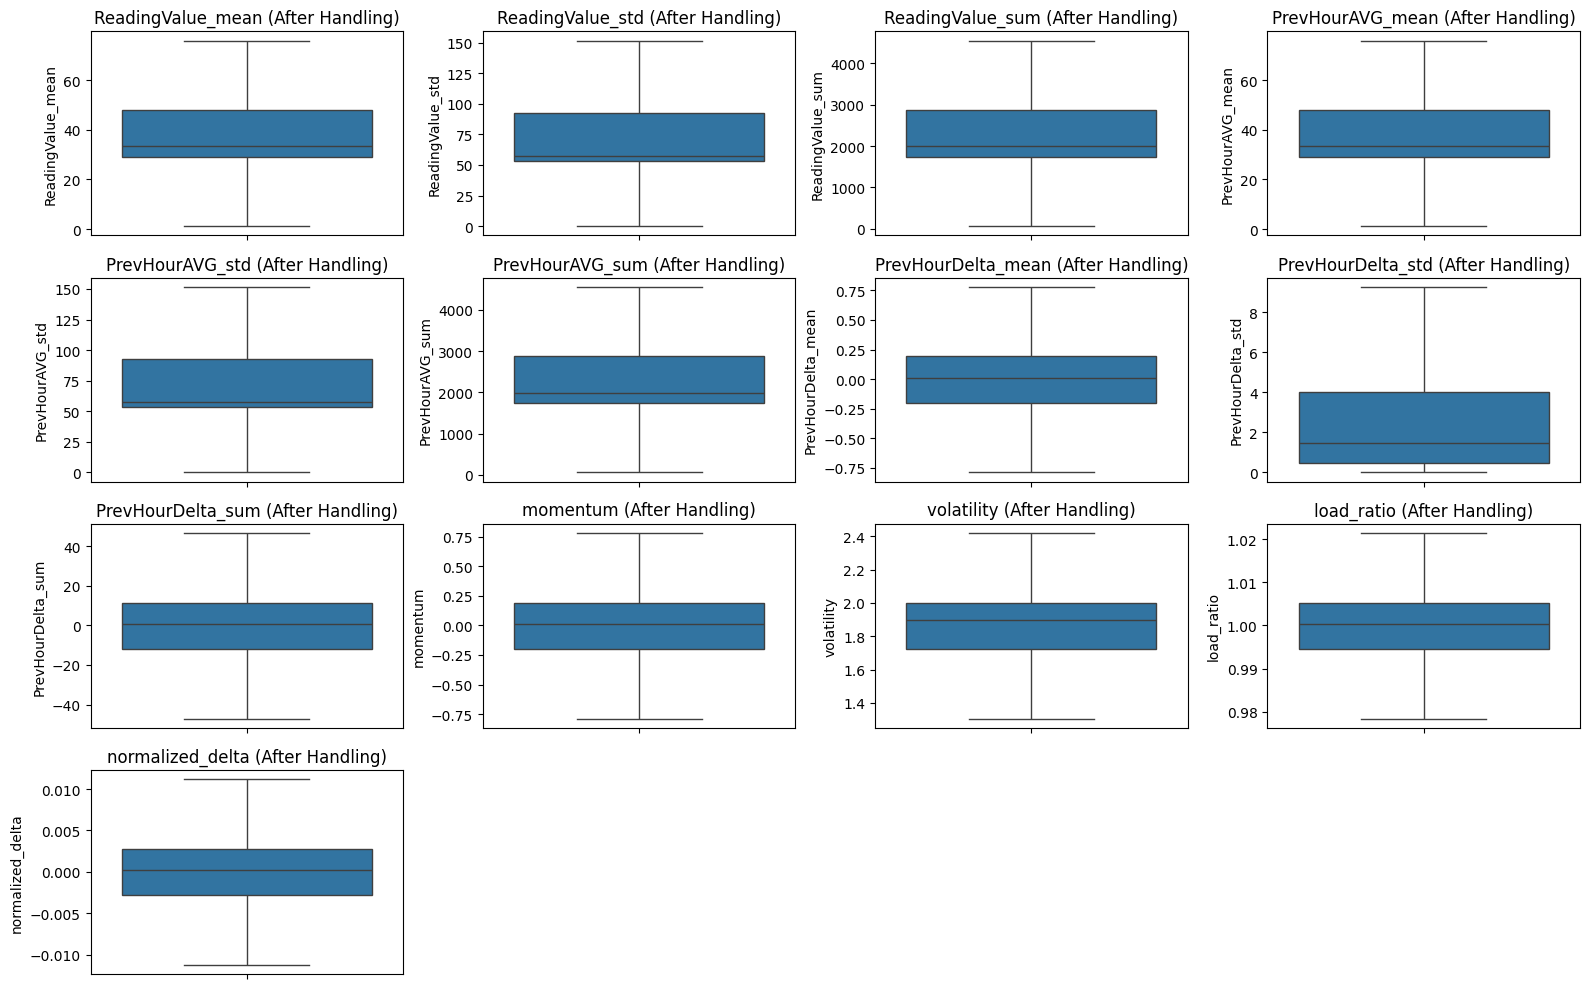

In [50]:
plt.figure(figsize=(16,10))

for i, col in enumerate(outlier_features, 1):

    plt.subplot(4,4,i)
    sns.boxplot(y=df_clean[col])
    plt.title(col + " (After Handling)")

plt.tight_layout()
plt.show()

**SKEWNESS**

Skewness values:
load_ratio             8.775737
PrevHourDelta_std      4.675263
volatility             2.367284
PrevHourAVG_mean       0.882905
ReadingValue_mean      0.879087
PrevHourAVG_std        0.878780
ReadingValue_std       0.876632
PrevHourAVG_sum        0.875163
ReadingValue_sum       0.873271
PrevHourDelta_sum     -0.615679
PrevHourDelta_mean    -1.455212
momentum              -1.455212
normalized_delta     -32.185687
dtype: float64


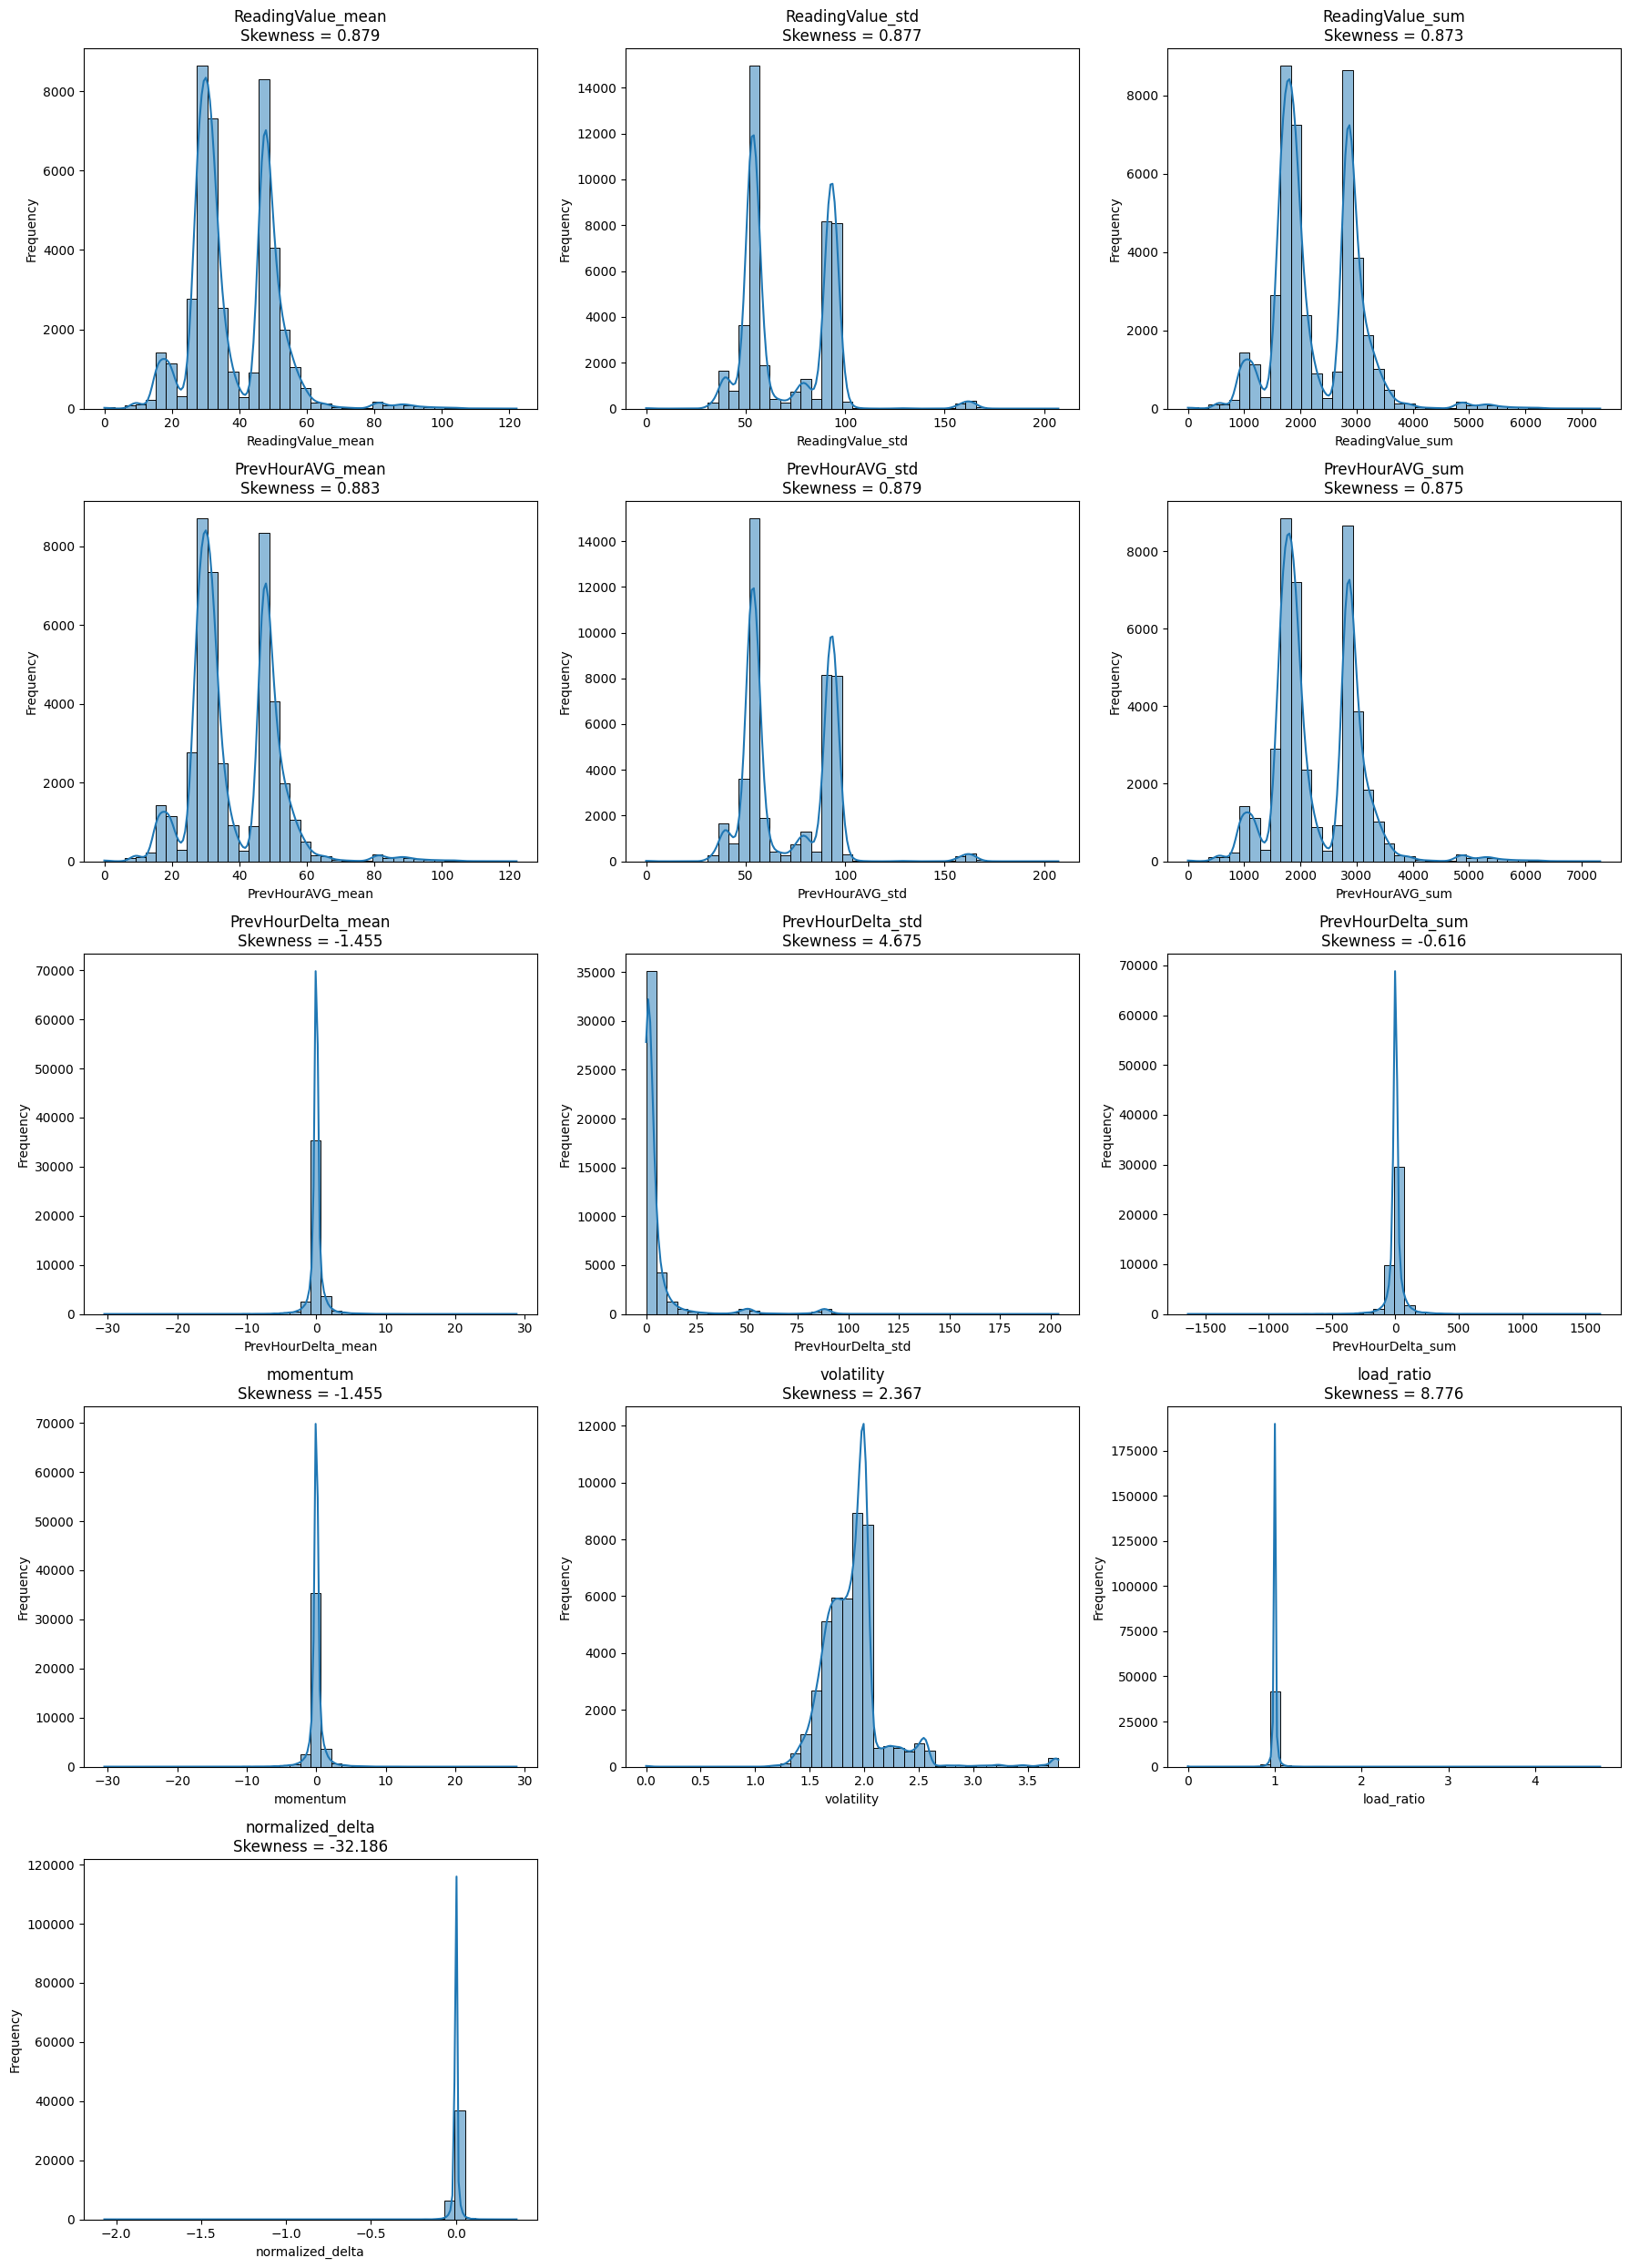

In [55]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "ReadingValue_mean",
    "ReadingValue_std",
    "ReadingValue_sum",
    "PrevHourAVG_mean",
    "PrevHourAVG_std",
    "PrevHourAVG_sum",
    "PrevHourDelta_mean",
    "PrevHourDelta_std",
    "PrevHourDelta_sum",
    "momentum",
    "volatility",
    "load_ratio",
    "normalized_delta"
]

features = [col for col in features if col in df.columns]

skew_values = df[features].skew().sort_values(ascending=False)
print("Skewness values:")
print(skew_values)

n = len(features)
ncols = 3
nrows = math.ceil(n / ncols)

plt.figure(figsize=(18, 5 * nrows))

for i, col in enumerate(features, 1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(df[col].dropna(), kde=True, bins=40)
    plt.title(f"{col}\nSkewness = {df[col].skew():.3f}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [51]:
features = [
    "ReadingValue_mean",
    "ReadingValue_std",
    "ReadingValue_sum",
    "PrevHourAVG_mean",
    "PrevHourAVG_std",
    "PrevHourAVG_sum",
    "PrevHourDelta_mean",
    "PrevHourDelta_std",
    "PrevHourDelta_sum",
    "hour",
    "momentum",
    "load_ratio",
    "volatility",
    "normalized_delta",
]

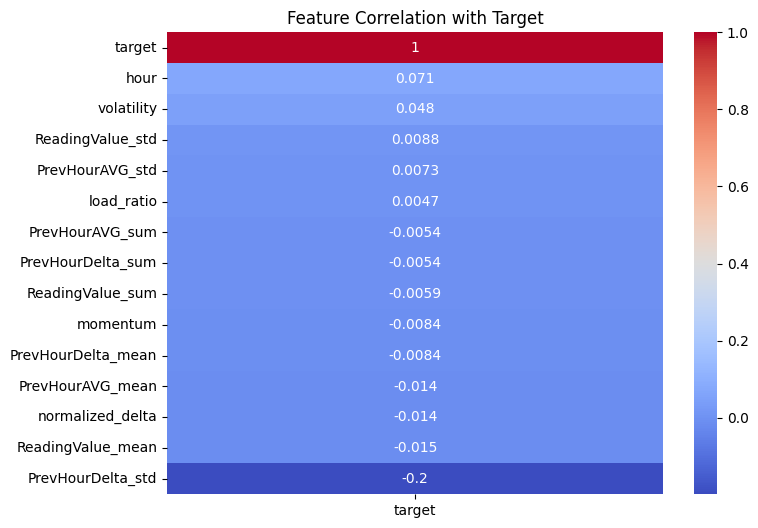

In [52]:
corr = df[features + ["target"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr[["target"]].sort_values("target", ascending=False),
            annot=True, cmap="coolwarm")
plt.title("Feature Correlation with Target")
plt.show()

**TRAIN ( RANDOM FOREST )**

Number of candidate features: 14
['ReadingValue_mean', 'ReadingValue_std', 'ReadingValue_sum', 'PrevHourAVG_mean', 'PrevHourAVG_std', 'PrevHourAVG_sum', 'PrevHourDelta_mean', 'PrevHourDelta_std', 'PrevHourDelta_sum', 'hour', 'momentum', 'load_ratio', 'volatility', 'normalized_delta']

Train meters: 1541
Test meters : 386
Train rows  : 34840
Test rows   : 8744

Train target distribution:
target
0    0.507577
1    0.492423
Name: proportion, dtype: float64

Test target distribution:
target
1    0.500114
0    0.499886
Name: proportion, dtype: float64

Top correlated features with target (train only):
1. PrevHourDelta_std --> corr = -0.1963
2. hour --> corr = 0.0691
3. volatility --> corr = 0.0476
4. normalized_delta --> corr = -0.0195
5. PrevHourDelta_mean --> corr = -0.0150
6. momentum --> corr = -0.0150
7. ReadingValue_mean --> corr = -0.0139
8. PrevHourAVG_mean --> corr = -0.0124
9. PrevHourDelta_sum --> corr = -0.0117
10. ReadingValue_std --> corr = 0.0087
11. PrevHourAVG_std --> corr 

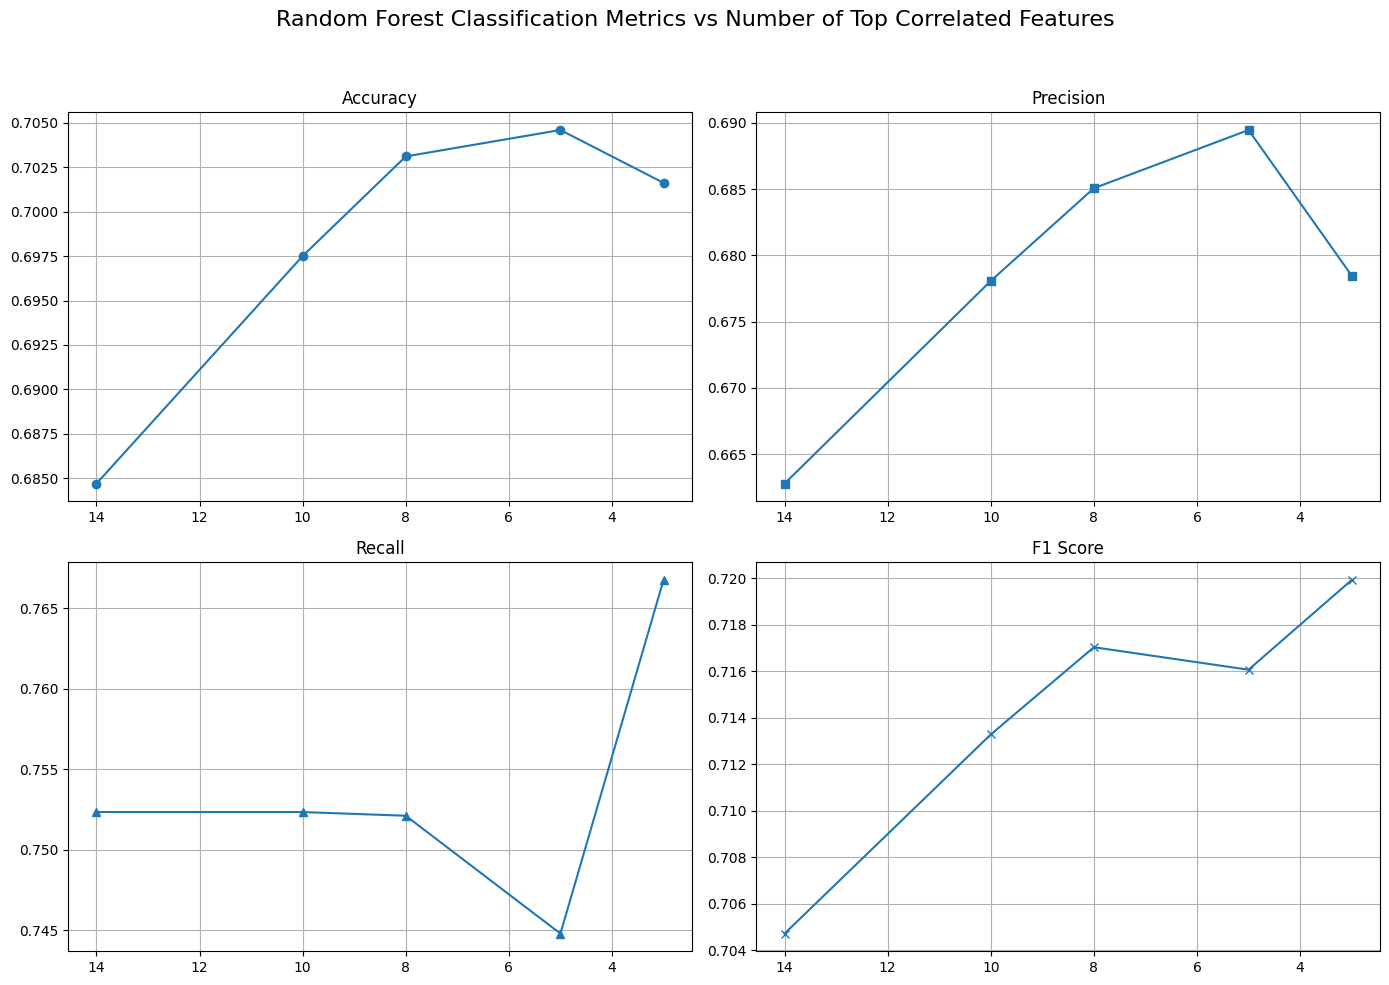


######################################################################
MODEL USING TOP 14 FEATURES
######################################################################
Features: ['PrevHourDelta_std', 'hour', 'volatility', 'normalized_delta', 'PrevHourDelta_mean', 'momentum', 'ReadingValue_mean', 'PrevHourAVG_mean', 'PrevHourDelta_sum', 'ReadingValue_std', 'PrevHourAVG_std', 'ReadingValue_sum', 'PrevHourAVG_sum', 'load_ratio']
Accuracy : 0.6847
Precision: 0.6628
Recall   : 0.7523
F1 Score : 0.7047
AUC      : 0.7632

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.62      0.66      4371
           1       0.66      0.75      0.70      4373

    accuracy                           0.68      8744
   macro avg       0.69      0.68      0.68      8744
weighted avg       0.69      0.68      0.68      8744



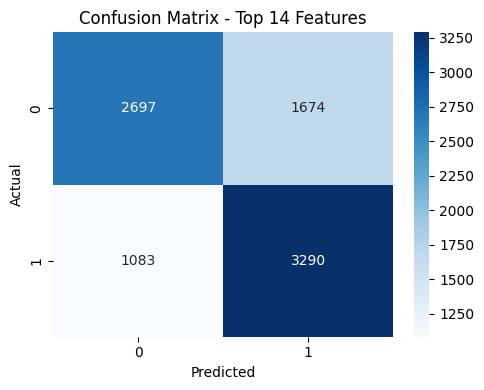

Feature Importance:
hour                  0.324523
PrevHourDelta_std     0.189800
volatility            0.060010
normalized_delta      0.058803
load_ratio            0.055177
momentum              0.047020
PrevHourDelta_sum     0.044287
PrevHourDelta_mean    0.041341
PrevHourAVG_std       0.035905
ReadingValue_std      0.032105
ReadingValue_sum      0.028115
ReadingValue_mean     0.028036
PrevHourAVG_sum       0.027939
PrevHourAVG_mean      0.026939
dtype: float64


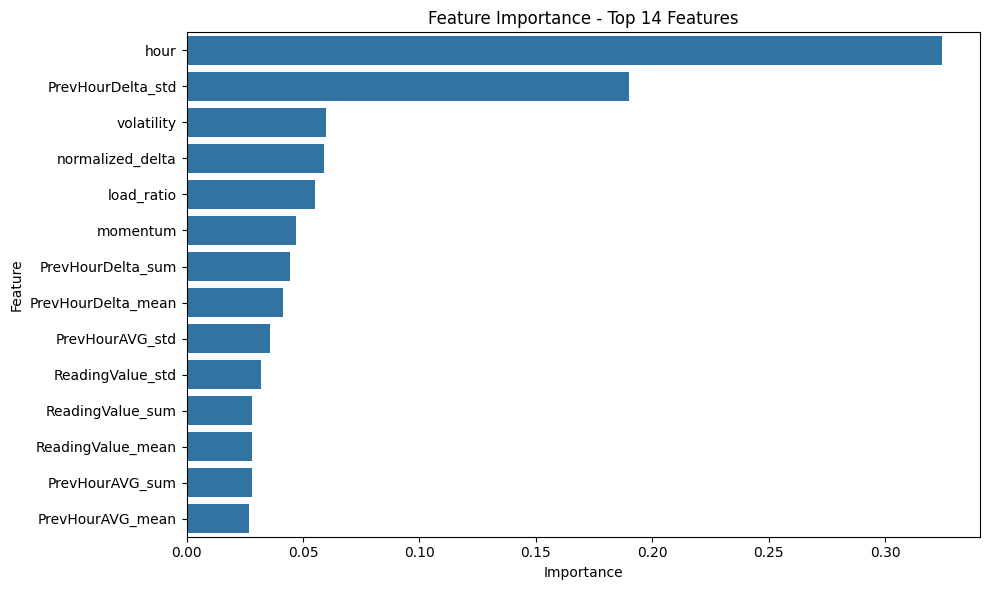


######################################################################
MODEL USING TOP 10 FEATURES
######################################################################
Features: ['PrevHourDelta_std', 'hour', 'volatility', 'normalized_delta', 'PrevHourDelta_mean', 'momentum', 'ReadingValue_mean', 'PrevHourAVG_mean', 'PrevHourDelta_sum', 'ReadingValue_std']
Accuracy : 0.6975
Precision: 0.6781
Recall   : 0.7523
F1 Score : 0.7133
AUC      : 0.7729

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.64      0.68      4371
           1       0.68      0.75      0.71      4373

    accuracy                           0.70      8744
   macro avg       0.70      0.70      0.70      8744
weighted avg       0.70      0.70      0.70      8744



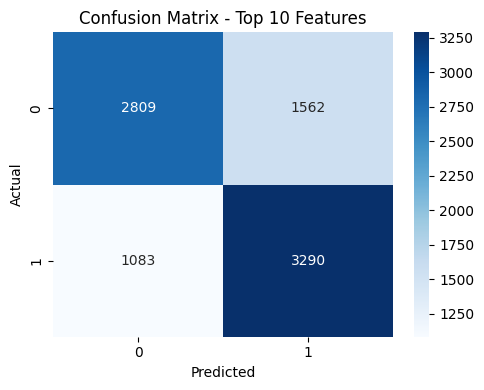

Feature Importance:
hour                  0.371254
PrevHourDelta_std     0.215536
volatility            0.070968
normalized_delta      0.067236
PrevHourDelta_mean    0.053297
momentum              0.052213
PrevHourDelta_sum     0.049909
ReadingValue_std      0.042780
PrevHourAVG_mean      0.039625
ReadingValue_mean     0.037182
dtype: float64


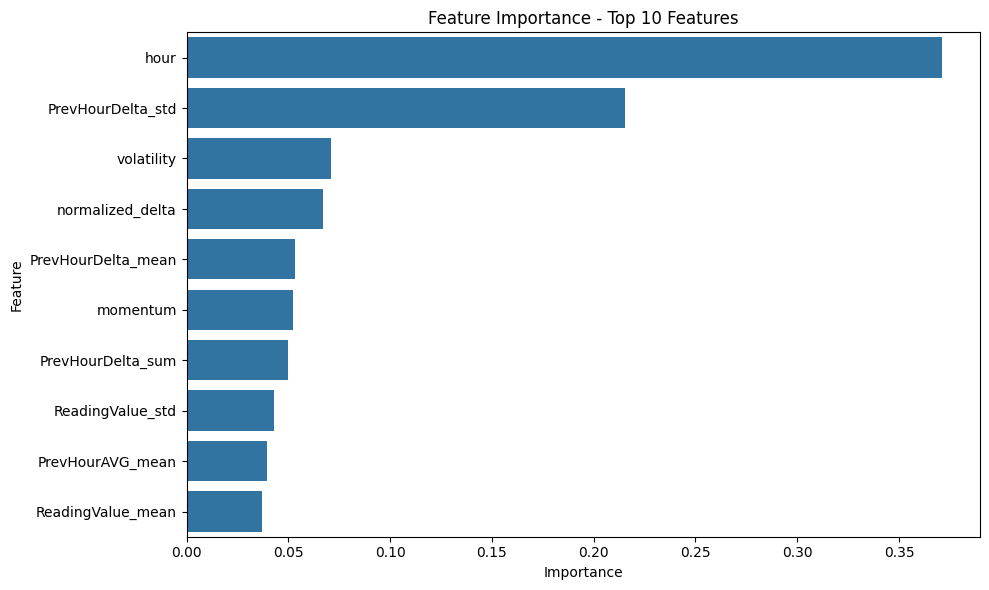


######################################################################
MODEL USING TOP 8 FEATURES
######################################################################
Features: ['PrevHourDelta_std', 'hour', 'volatility', 'normalized_delta', 'PrevHourDelta_mean', 'momentum', 'ReadingValue_mean', 'PrevHourAVG_mean']
Accuracy : 0.7031
Precision: 0.6851
Recall   : 0.7521
F1 Score : 0.7170
AUC      : 0.7784

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.65      0.69      4371
           1       0.69      0.75      0.72      4373

    accuracy                           0.70      8744
   macro avg       0.71      0.70      0.70      8744
weighted avg       0.71      0.70      0.70      8744



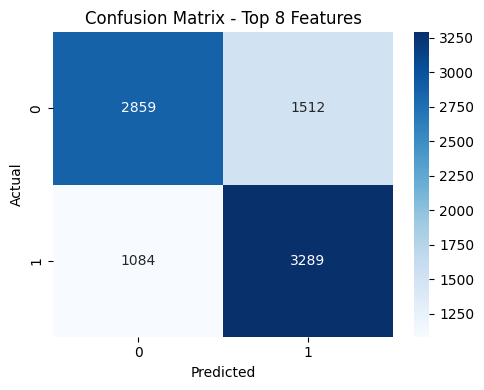

Feature Importance:
hour                  0.405765
PrevHourDelta_std     0.217680
normalized_delta      0.081624
volatility            0.081374
PrevHourDelta_mean    0.063149
momentum              0.060082
PrevHourAVG_mean      0.045191
ReadingValue_mean     0.045136
dtype: float64


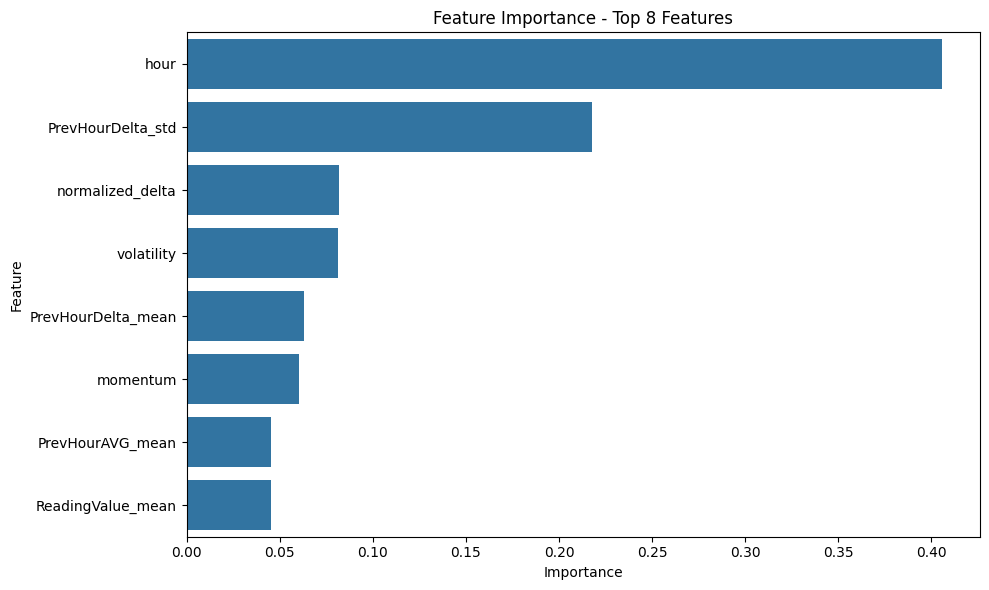


######################################################################
MODEL USING TOP 5 FEATURES
######################################################################
Features: ['PrevHourDelta_std', 'hour', 'volatility', 'normalized_delta', 'PrevHourDelta_mean']
Accuracy : 0.7046
Precision: 0.6895
Recall   : 0.7448
F1 Score : 0.7161
AUC      : 0.7786

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.66      0.69      4371
           1       0.69      0.74      0.72      4373

    accuracy                           0.70      8744
   macro avg       0.71      0.70      0.70      8744
weighted avg       0.71      0.70      0.70      8744



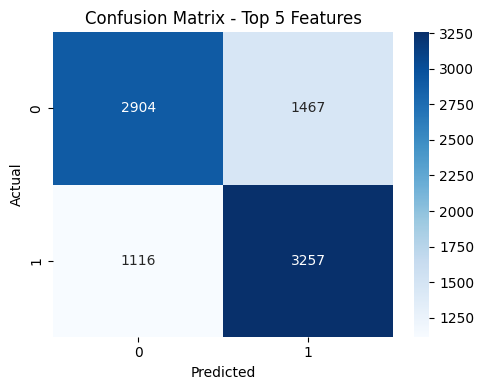

Feature Importance:
hour                  0.433943
PrevHourDelta_std     0.244933
normalized_delta      0.115616
volatility            0.105277
PrevHourDelta_mean    0.100230
dtype: float64


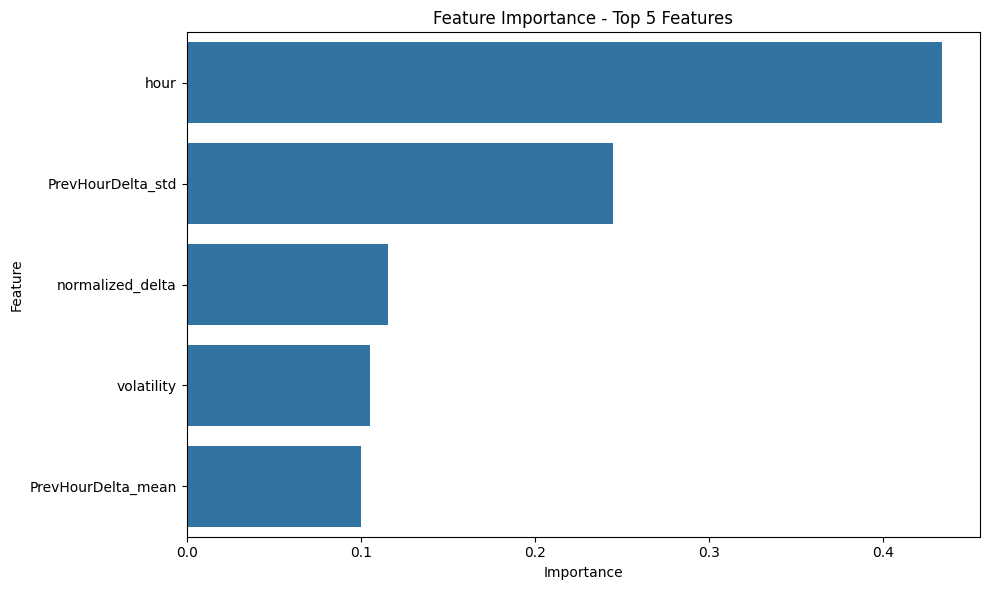


######################################################################
MODEL USING TOP 3 FEATURES
######################################################################
Features: ['PrevHourDelta_std', 'hour', 'volatility']
Accuracy : 0.7016
Precision: 0.6785
Recall   : 0.7668
F1 Score : 0.7199
AUC      : 0.7728

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.64      0.68      4371
           1       0.68      0.77      0.72      4373

    accuracy                           0.70      8744
   macro avg       0.71      0.70      0.70      8744
weighted avg       0.71      0.70      0.70      8744



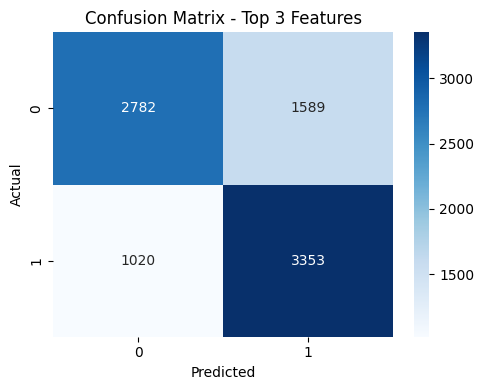

Feature Importance:
hour                 0.592310
PrevHourDelta_std    0.266251
volatility           0.141439
dtype: float64


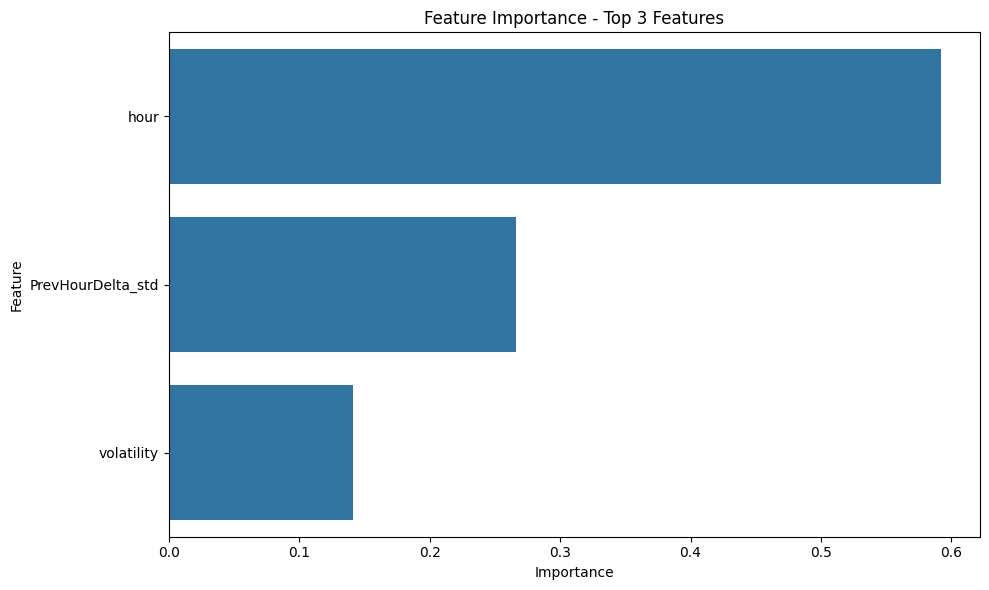


FINAL BEST MODEL BASED ON ACCURACY = TOP 5 FEATURES
Best features: ['PrevHourDelta_std', 'hour', 'volatility', 'normalized_delta', 'PrevHourDelta_mean']
Best params  : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [53]:
# =========================================================
# ELECTRICITY TASK - CLASSIFICATION
# Predict: Will next hour increase? (target = 0/1)
# Train RandomForestClassifier on top correlated features
# using TRAIN-ONLY correlation + MeterID split
# BEST MODEL BASED ON ACCURACY
# SHOW GRAPHS FOR EACH TOP-N MODEL
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# ---------------------------------------------------------
# 1) COPY DATA
# ---------------------------------------------------------
df_model = df.copy()

# ---------------------------------------------------------
# 2) SAFETY CHECKS
# ---------------------------------------------------------
required_cols = [
    "MeterID", "ReadingTime",
    "ReadingValue_mean", "ReadingValue_std", "ReadingValue_sum",
    "PrevHourAVG_mean", "PrevHourAVG_std", "PrevHourAVG_sum",
    "PrevHourDelta_mean", "PrevHourDelta_std", "PrevHourDelta_sum",
    "hour", "momentum", "load_ratio", "volatility", "normalized_delta",
    "target"
]

missing_cols = [c for c in required_cols if c not in df_model.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# ---------------------------------------------------------
# 3) DEFINE CANDIDATE FEATURES
# ---------------------------------------------------------
candidate_features = [
    "ReadingValue_mean",
    "ReadingValue_std",
    "ReadingValue_sum",
    "PrevHourAVG_mean",
    "PrevHourAVG_std",
    "PrevHourAVG_sum",
    "PrevHourDelta_mean",
    "PrevHourDelta_std",
    "PrevHourDelta_sum",
    "hour",
    "momentum",
    "load_ratio",
    "volatility",
    "normalized_delta",
]

candidate_features = [c for c in candidate_features if c in df_model.columns]

# Extra leakage safety check
for bad_col in ["target", "target_next_hour", "next_hour_value", "MeterID", "ReadingTime"]:
    if bad_col in candidate_features:
        raise ValueError(f"Leakage column found in candidate_features: {bad_col}")

print("Number of candidate features:", len(candidate_features))
print(candidate_features)

# ---------------------------------------------------------
# 4) SPLIT BY METERID
# ---------------------------------------------------------
meters = np.array(sorted(df_model["MeterID"].unique()))
split_idx = int(len(meters) * 0.8)

train_meters = meters[:split_idx]
test_meters = meters[split_idx:]

train_df = df_model[df_model["MeterID"].isin(train_meters)].copy()
test_df  = df_model[df_model["MeterID"].isin(test_meters)].copy()

print("\nTrain meters:", len(train_meters))
print("Test meters :", len(test_meters))
print("Train rows  :", train_df.shape[0])
print("Test rows   :", test_df.shape[0])

print("\nTrain target distribution:")
print(train_df["target"].value_counts(normalize=True))

print("\nTest target distribution:")
print(test_df["target"].value_counts(normalize=True))

# ---------------------------------------------------------
# 5) COMPUTE FEATURE CORRELATION WITH TARGET
# ONLY ON TRAINING DATA
# ---------------------------------------------------------
train_corr_df = train_df[candidate_features + ["target"]].copy()
corr_with_target = train_corr_df.corr(numeric_only=True)["target"].drop("target")

top_features_ranked = corr_with_target.abs().sort_values(ascending=False).index.tolist()

print("\nTop correlated features with target (train only):")
for i, feat in enumerate(top_features_ranked, 1):
    print(f"{i}. {feat} --> corr = {corr_with_target[feat]:.4f}")

# ---------------------------------------------------------
# 6) DEFINE RANDOM FOREST PARAMETER GRID
# ---------------------------------------------------------
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

candidate_counts = [len(top_features_ranked), 10, 8, 5, 3]
top_n_feature_counts = [x for x in candidate_counts if x <= len(top_features_ranked)]
top_n_feature_counts = list(dict.fromkeys(top_n_feature_counts))

results = []
pred_store = []

# ---------------------------------------------------------
# 7) TRAIN DIFFERENT TOP-N FEATURE SUBSETS
# ---------------------------------------------------------
for count in top_n_feature_counts:
    print("\n" + "=" * 60)
    print(f"TRAINING CLASSIFIER WITH TOP {count} CORRELATED FEATURES")
    print("=" * 60)

    selected_features = top_features_ranked[:count]

    X_train = train_df[selected_features]
    y_train = train_df["target"]

    X_test = test_df[selected_features]
    y_test = test_df["target"]

    rf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    grid = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring="accuracy",   # changed from f1 to accuracy
        cv=3,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    print("Best params:", grid.best_params_)
    print("Selected features:", selected_features)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    results.append({
        "Top_N_Features": count,
        "Selected_Features": selected_features,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "Best_Params": grid.best_params_
    })

    pred_store.append({
        "Top_N_Features": count,
        "y_true": y_test.values,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "model": best_model,
        "features": selected_features
    })

# ---------------------------------------------------------
# 8) RESULTS TABLE
# ---------------------------------------------------------
results_df = pd.DataFrame(results)

print("\n================ CLASSIFICATION RESULTS ================\n")
print(results_df[["Top_N_Features", "Accuracy", "Precision", "Recall", "F1", "AUC"]])

# BEST MODEL NOW BASED ON ACCURACY
best_row = results_df.sort_values("Accuracy", ascending=False).iloc[0]

print("\nBEST CLASSIFICATION SETUP BASED ON ACCURACY:")
print("Top_N_Features:", best_row["Top_N_Features"])
print("Best Accuracy :", round(best_row["Accuracy"], 4))
print("Best F1       :", round(best_row["F1"], 4))
print("Best AUC      :", round(best_row["AUC"], 4))
print("Best Features :", best_row["Selected_Features"])
print("Best Params   :", best_row["Best_Params"])

# ---------------------------------------------------------
# 9) OVERALL METRIC PLOTS
# ---------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Random Forest Classification Metrics vs Number of Top Correlated Features", fontsize=16)

axs[0, 0].plot(results_df["Top_N_Features"], results_df["Accuracy"], marker="o")
axs[0, 0].set_title("Accuracy")
axs[0, 0].invert_xaxis()
axs[0, 0].grid(True)

axs[0, 1].plot(results_df["Top_N_Features"], results_df["Precision"], marker="s")
axs[0, 1].set_title("Precision")
axs[0, 1].invert_xaxis()
axs[0, 1].grid(True)

axs[1, 0].plot(results_df["Top_N_Features"], results_df["Recall"], marker="^")
axs[1, 0].set_title("Recall")
axs[1, 0].invert_xaxis()
axs[1, 0].grid(True)

axs[1, 1].plot(results_df["Top_N_Features"], results_df["F1"], marker="x")
axs[1, 1].set_title("F1 Score")
axs[1, 1].invert_xaxis()
axs[1, 1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---------------------------------------------------------
# 10) GRAPH + REPORT FOR EACH MODEL
# ---------------------------------------------------------
for rec in pred_store:
    top_n = rec["Top_N_Features"]
    y_true = rec["y_true"]
    y_pred = rec["y_pred"]
    y_prob = rec["y_prob"]
    model = rec["model"]
    features = rec["features"]

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    print("\n" + "#" * 70)
    print(f"MODEL USING TOP {top_n} FEATURES")
    print("#" * 70)
    print("Features:", features)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - Top {top_n} Features")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Feature Importance
    # -----------------------------
    importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

    print("Feature Importance:")
    print(importance)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance.values, y=importance.index)
    plt.title(f"Feature Importance - Top {top_n} Features")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 11) SHOW BEST MODEL AGAIN BASED ON ACCURACY
# ---------------------------------------------------------
best_top_n = best_row["Top_N_Features"]

best_record = None
for rec in pred_store:
    if rec["Top_N_Features"] == best_top_n:
        best_record = rec
        break

print("\n" + "=" * 70)
print(f"FINAL BEST MODEL BASED ON ACCURACY = TOP {best_top_n} FEATURES")
print("=" * 70)
print("Best features:", best_record["features"])
print("Best params  :", best_row["Best_Params"])

Candidate features:
['ReadingValue_mean', 'ReadingValue_std', 'ReadingValue_sum', 'PrevHourAVG_mean', 'PrevHourAVG_std', 'PrevHourAVG_sum', 'PrevHourDelta_mean', 'PrevHourDelta_std', 'PrevHourDelta_sum', 'hour', 'momentum', 'load_ratio', 'volatility', 'normalized_delta']

Train meters: 1541
Test meters : 386
Train rows  : 34840
Test rows   : 8744

Train target distribution:
target
0    0.507577
1    0.492423
Name: proportion, dtype: float64

Test target distribution:
target
1    0.500114
0    0.499886
Name: proportion, dtype: float64

Top correlated features with target (train only):
1. PrevHourDelta_std --> corr = -0.1963
2. hour --> corr = 0.0691
3. volatility --> corr = 0.0476
4. normalized_delta --> corr = -0.0195
5. PrevHourDelta_mean --> corr = -0.0150
6. momentum --> corr = -0.0150
7. ReadingValue_mean --> corr = -0.0139
8. PrevHourAVG_mean --> corr = -0.0124
9. PrevHourDelta_sum --> corr = -0.0117
10. ReadingValue_std --> corr = 0.0087
11. PrevHourAVG_std --> corr = 0.0074
12. 

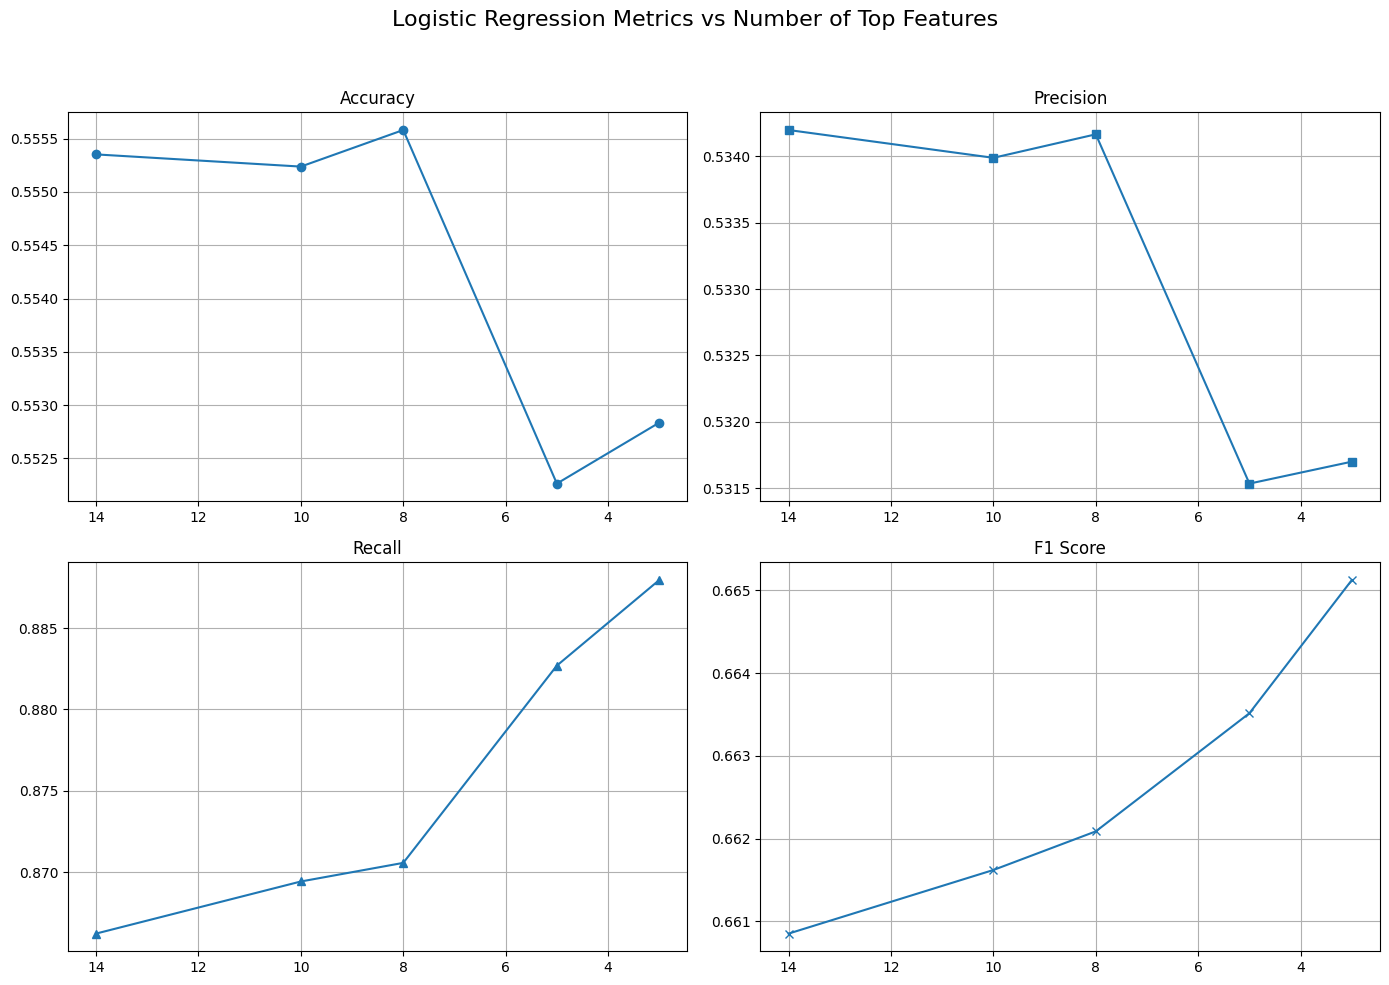


################################################################################
MODEL USING TOP 14 FEATURES
################################################################################
Features: ['PrevHourDelta_std', 'hour', 'volatility', 'normalized_delta', 'PrevHourDelta_mean', 'momentum', 'ReadingValue_mean', 'PrevHourAVG_mean', 'PrevHourDelta_sum', 'ReadingValue_std', 'PrevHourAVG_std', 'ReadingValue_sum', 'PrevHourAVG_sum', 'load_ratio']
Accuracy : 0.5554
Precision: 0.5342
Recall   : 0.8662
F1 Score : 0.6609
AUC      : 0.6131

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.24      0.35      4371
           1       0.53      0.87      0.66      4373

    accuracy                           0.56      8744
   macro avg       0.59      0.56      0.51      8744
weighted avg       0.59      0.56      0.51      8744



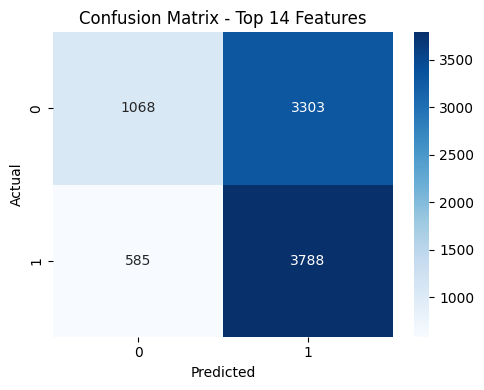

Top Positive Features:
ReadingValue_std     3.100882
PrevHourDelta_sum    1.832325
ReadingValue_sum     0.440677
load_ratio           0.326261
PrevHourAVG_sum      0.266369
dtype: float64

Top Negative Features:
ReadingValue_mean    -0.449829
PrevHourDelta_std    -0.675623
PrevHourDelta_mean   -0.971581
momentum             -0.971581
PrevHourAVG_std      -2.962694
dtype: float64


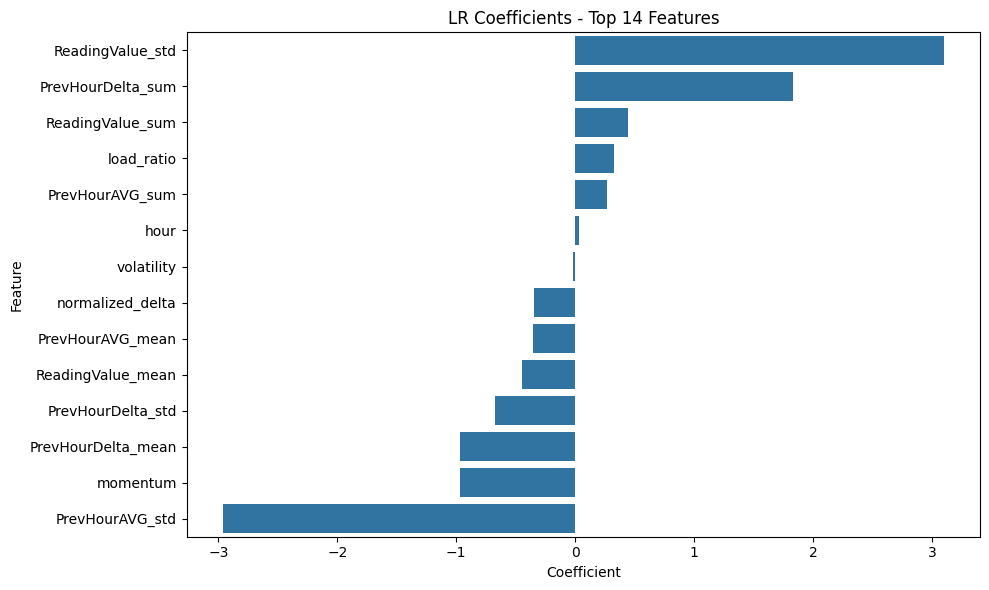


################################################################################
MODEL USING TOP 10 FEATURES
################################################################################
Features: ['PrevHourDelta_std', 'hour', 'volatility', 'normalized_delta', 'PrevHourDelta_mean', 'momentum', 'ReadingValue_mean', 'PrevHourAVG_mean', 'PrevHourDelta_sum', 'ReadingValue_std']
Accuracy : 0.5552
Precision: 0.5340
Recall   : 0.8694
F1 Score : 0.6616
AUC      : 0.5816

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.24      0.35      4371
           1       0.53      0.87      0.66      4373

    accuracy                           0.56      8744
   macro avg       0.59      0.56      0.51      8744
weighted avg       0.59      0.56      0.51      8744



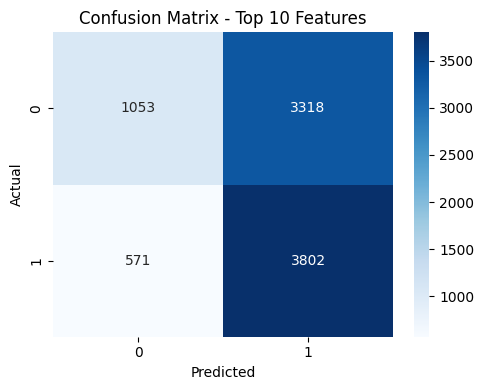

Top Positive Features:
PrevHourDelta_sum    0.435956
ReadingValue_std     0.086247
hour                 0.029303
volatility           0.015402
PrevHourAVG_mean    -0.007375
dtype: float64

Top Negative Features:
ReadingValue_mean    -0.027896
normalized_delta     -0.072827
PrevHourDelta_mean   -0.208186
momentum             -0.208186
PrevHourDelta_std    -0.649758
dtype: float64


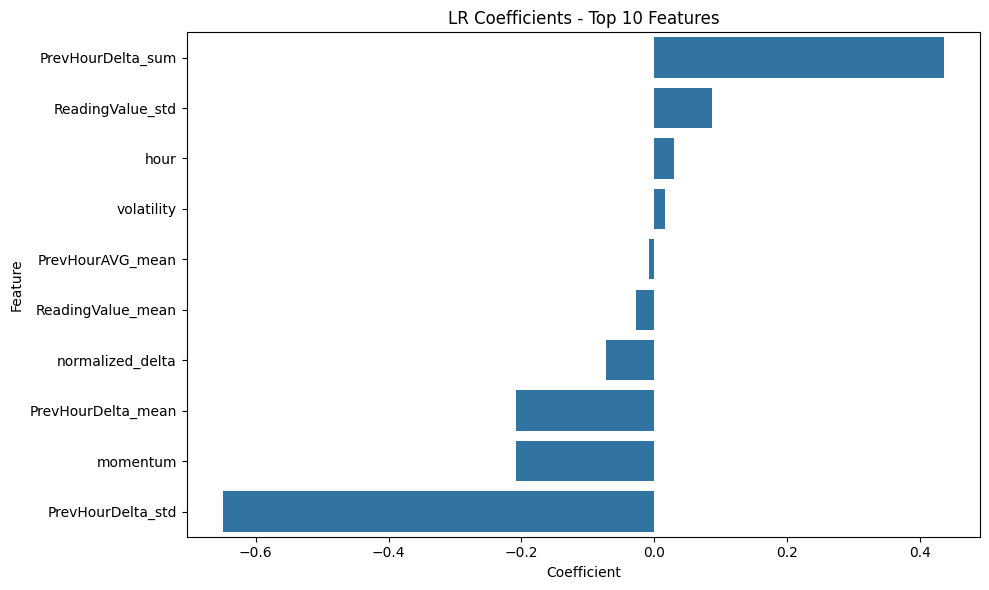


################################################################################
MODEL USING TOP 8 FEATURES
>>> THIS IS THE BEST MODEL BASED ON ACCURACY <<<
################################################################################
Features: ['PrevHourDelta_std', 'hour', 'volatility', 'normalized_delta', 'PrevHourDelta_mean', 'momentum', 'ReadingValue_mean', 'PrevHourAVG_mean']
Accuracy : 0.5556
Precision: 0.5342
Recall   : 0.8706
F1 Score : 0.6621
AUC      : 0.5795

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.24      0.35      4371
           1       0.53      0.87      0.66      4373

    accuracy                           0.56      8744
   macro avg       0.59      0.56      0.51      8744
weighted avg       0.59      0.56      0.51      8744



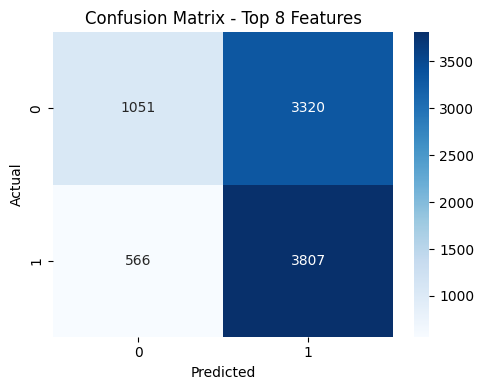

Top Positive Features:
volatility            0.040796
momentum              0.037638
PrevHourDelta_mean    0.037638
ReadingValue_mean     0.029089
hour                  0.028644
dtype: float64

Top Negative Features:
ReadingValue_mean    0.029089
hour                 0.028644
PrevHourAVG_mean     0.025386
normalized_delta    -0.138114
PrevHourDelta_std   -0.659430
dtype: float64


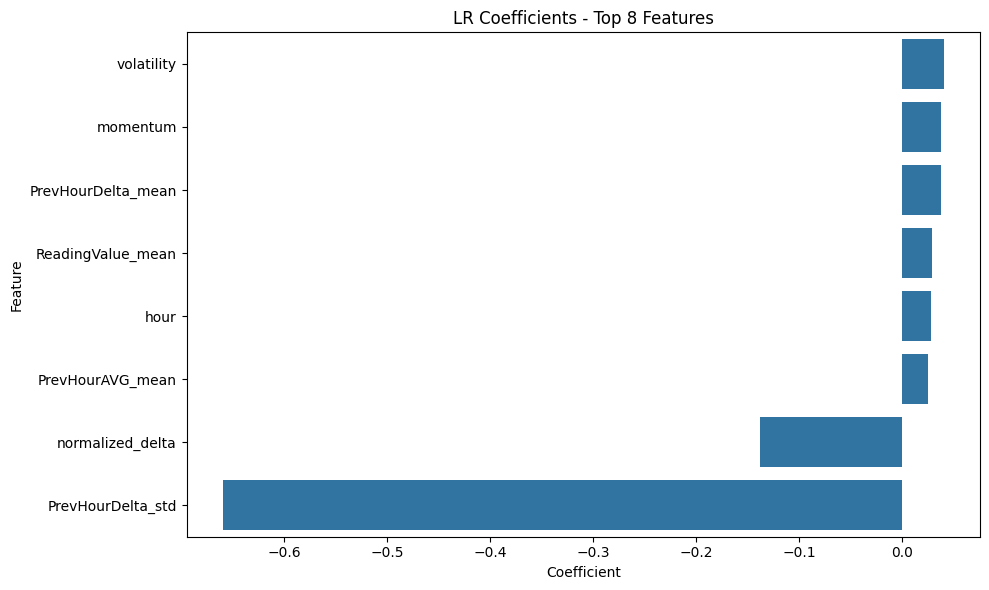


################################################################################
MODEL USING TOP 5 FEATURES
################################################################################
Features: ['PrevHourDelta_std', 'hour', 'volatility', 'normalized_delta', 'PrevHourDelta_mean']
Accuracy : 0.5523
Precision: 0.5315
Recall   : 0.8827
F1 Score : 0.6635
AUC      : 0.5775

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.22      0.33      4371
           1       0.53      0.88      0.66      4373

    accuracy                           0.55      8744
   macro avg       0.59      0.55      0.50      8744
weighted avg       0.59      0.55      0.50      8744



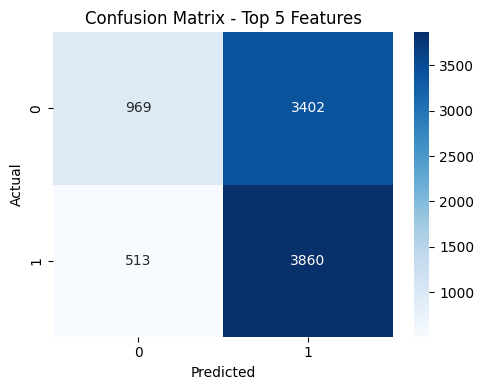

Top Positive Features:
PrevHourDelta_mean    0.054534
hour                  0.030157
volatility            0.027242
normalized_delta     -0.111061
PrevHourDelta_std    -0.620503
dtype: float64

Top Negative Features:
PrevHourDelta_mean    0.054534
hour                  0.030157
volatility            0.027242
normalized_delta     -0.111061
PrevHourDelta_std    -0.620503
dtype: float64


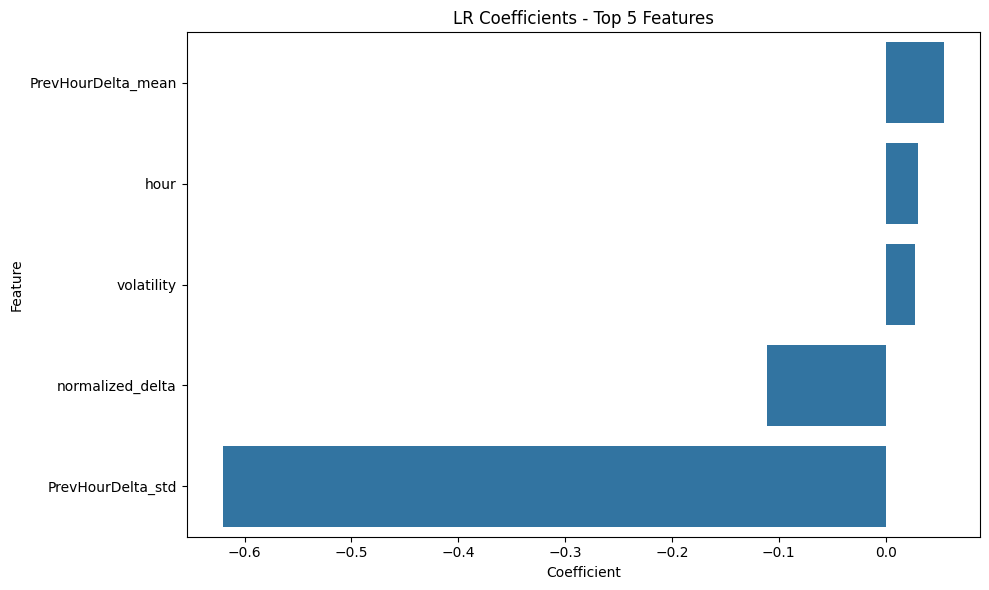


################################################################################
MODEL USING TOP 3 FEATURES
################################################################################
Features: ['PrevHourDelta_std', 'hour', 'volatility']
Accuracy : 0.5528
Precision: 0.5317
Recall   : 0.8879
F1 Score : 0.6651
AUC      : 0.5796

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.22      0.33      4371
           1       0.53      0.89      0.67      4373

    accuracy                           0.55      8744
   macro avg       0.60      0.55      0.50      8744
weighted avg       0.60      0.55      0.50      8744



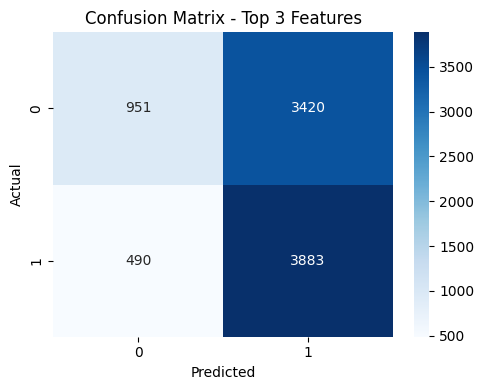

Top Positive Features:
hour                 0.031000
volatility           0.029556
PrevHourDelta_std   -0.614720
dtype: float64

Top Negative Features:
hour                 0.031000
volatility           0.029556
PrevHourDelta_std   -0.614720
dtype: float64


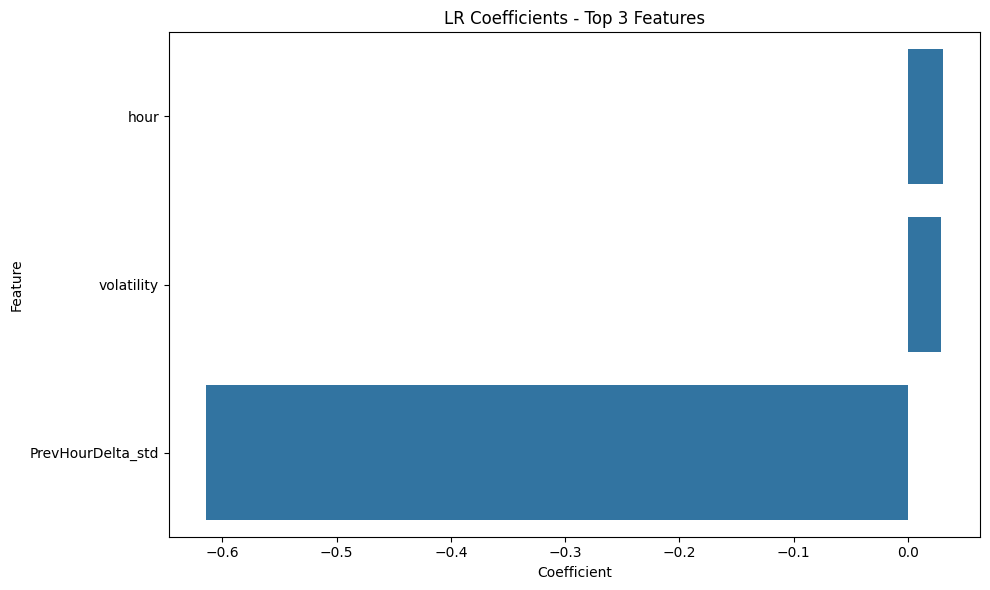


FINAL WINNER
Best model uses TOP 8 FEATURES
Best accuracy = 0.5556
Best params   = {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best features = ['PrevHourDelta_std', 'hour', 'volatility', 'normalized_delta', 'PrevHourDelta_mean', 'momentum', 'ReadingValue_mean', 'PrevHourAVG_mean']


In [54]:
# =========================================================
# ELECTRICITY TASK - CLASSIFICATION
# Logistic Regression Version
# SHOW ALL MODELS + CLEARLY PRINT BEST MODEL BY ACCURACY
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# ---------------------------------------------------------
# 1) COPY DATA
# ---------------------------------------------------------
df_model = df.copy()

# ---------------------------------------------------------
# 2) SAFETY CHECKS
# ---------------------------------------------------------
required_cols = [
    "MeterID", "ReadingTime",
    "ReadingValue_mean", "ReadingValue_std", "ReadingValue_sum",
    "PrevHourAVG_mean", "PrevHourAVG_std", "PrevHourAVG_sum",
    "PrevHourDelta_mean", "PrevHourDelta_std", "PrevHourDelta_sum",
    "hour", "momentum", "load_ratio", "volatility", "normalized_delta",
    "target"
]

missing_cols = [c for c in required_cols if c not in df_model.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# ---------------------------------------------------------
# 3) DEFINE CANDIDATE FEATURES
# ---------------------------------------------------------
candidate_features = [
    "ReadingValue_mean",
    "ReadingValue_std",
    "ReadingValue_sum",
    "PrevHourAVG_mean",
    "PrevHourAVG_std",
    "PrevHourAVG_sum",
    "PrevHourDelta_mean",
    "PrevHourDelta_std",
    "PrevHourDelta_sum",
    "hour",
    "momentum",
    "load_ratio",
    "volatility",
    "normalized_delta",
]

candidate_features = [c for c in candidate_features if c in df_model.columns]

for bad_col in ["target", "target_next_hour", "next_hour_value", "MeterID", "ReadingTime"]:
    if bad_col in candidate_features:
        raise ValueError(f"Leakage column found: {bad_col}")

print("Candidate features:")
print(candidate_features)

# ---------------------------------------------------------
# 4) SPLIT BY METERID
# ---------------------------------------------------------
meters = np.array(sorted(df_model["MeterID"].unique()))
split_idx = int(len(meters) * 0.8)

train_df = df_model[df_model["MeterID"].isin(meters[:split_idx])].copy()
test_df  = df_model[df_model["MeterID"].isin(meters[split_idx:])].copy()

print("\nTrain meters:", len(meters[:split_idx]))
print("Test meters :", len(meters[split_idx:]))
print("Train rows  :", train_df.shape[0])
print("Test rows   :", test_df.shape[0])

print("\nTrain target distribution:")
print(train_df["target"].value_counts(normalize=True))

print("\nTest target distribution:")
print(test_df["target"].value_counts(normalize=True))

# ---------------------------------------------------------
# 5) CORRELATION (TRAIN ONLY)
# ---------------------------------------------------------
train_corr_df = train_df[candidate_features + ["target"]].copy()
corr = train_corr_df.corr(numeric_only=True)["target"].drop("target")

top_features_ranked = corr.abs().sort_values(ascending=False).index.tolist()

print("\nTop correlated features with target (train only):")
for i, feat in enumerate(top_features_ranked, 1):
    print(f"{i}. {feat} --> corr = {corr[feat]:.4f}")

# ---------------------------------------------------------
# 6) LR PARAM GRID
# ---------------------------------------------------------
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

candidate_counts = [len(top_features_ranked), 10, 8, 5, 3]
top_n_feature_counts = [x for x in candidate_counts if x <= len(top_features_ranked)]
top_n_feature_counts = list(dict.fromkeys(top_n_feature_counts))

results = []
pred_store = []

# ---------------------------------------------------------
# 7) TRAIN LOOP
# ---------------------------------------------------------
for count in top_n_feature_counts:
    print("\n" + "=" * 60)
    print(f"TRAINING LR WITH TOP {count} FEATURES")
    print("=" * 60)

    selected_features = top_features_ranked[:count]

    X_train = train_df[selected_features]
    y_train = train_df["target"]

    X_test = test_df[selected_features]
    y_test = test_df["target"]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="accuracy",
        cv=3,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    print("Best params:", grid.best_params_)
    print("Features:", selected_features)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    results.append({
        "Top_N": count,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "Features": selected_features,
        "Params": grid.best_params_
    })

    pred_store.append({
        "Top_N": count,
        "y_true": y_test.values,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "model": best_model,
        "features": selected_features
    })

# ---------------------------------------------------------
# 8) RESULTS TABLE
# ---------------------------------------------------------
results_df = pd.DataFrame(results)

print("\n================ ALL LR RESULTS ================\n")
print(results_df[["Top_N", "Accuracy", "Precision", "Recall", "F1", "AUC"]])

# ---------------------------------------------------------
# 9) PRINT BEST MODEL CLEARLY
# ---------------------------------------------------------
best_row = results_df.sort_values("Accuracy", ascending=False).iloc[0]
best_top_n = best_row["Top_N"]

best_record = None
for rec in pred_store:
    if rec["Top_N"] == best_top_n:
        best_record = rec
        break

print("\n" + "=" * 80)
print("BEST MODEL BASED ON ACCURACY")
print("=" * 80)
print(f"Top_N Features : {best_row['Top_N']}")
print(f"Best Accuracy  : {best_row['Accuracy']:.4f}")
print(f"Precision      : {best_row['Precision']:.4f}")
print(f"Recall         : {best_row['Recall']:.4f}")
print(f"F1 Score       : {best_row['F1']:.4f}")
print(f"AUC            : {best_row['AUC']:.4f}")
print(f"Best Params    : {best_row['Params']}")
print(f"Best Features  : {best_row['Features']}")
print("=" * 80)

# ---------------------------------------------------------
# 10) PLOTS FOR ALL MODELS
# ---------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Logistic Regression Metrics vs Number of Top Features", fontsize=16)

axs[0, 0].plot(results_df["Top_N"], results_df["Accuracy"], marker="o")
axs[0, 0].set_title("Accuracy")
axs[0, 0].invert_xaxis()
axs[0, 0].grid(True)

axs[0, 1].plot(results_df["Top_N"], results_df["Precision"], marker="s")
axs[0, 1].set_title("Precision")
axs[0, 1].invert_xaxis()
axs[0, 1].grid(True)

axs[1, 0].plot(results_df["Top_N"], results_df["Recall"], marker="^")
axs[1, 0].set_title("Recall")
axs[1, 0].invert_xaxis()
axs[1, 0].grid(True)

axs[1, 1].plot(results_df["Top_N"], results_df["F1"], marker="x")
axs[1, 1].set_title("F1 Score")
axs[1, 1].invert_xaxis()
axs[1, 1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---------------------------------------------------------
# 11) DETAILED OUTPUT FOR ALL MODELS
# ---------------------------------------------------------
for rec in pred_store:
    current_top_n = rec["Top_N"]
    y_true = rec["y_true"]
    y_pred = rec["y_pred"]
    y_prob = rec["y_prob"]
    features = rec["features"]
    model = rec["model"]

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    print("\n" + "#" * 80)
    print(f"MODEL USING TOP {current_top_n} FEATURES")
    if current_top_n == best_top_n:
        print(">>> THIS IS THE BEST MODEL BASED ON ACCURACY <<<")
    print("#" * 80)

    print("Features:", features)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - Top {current_top_n} Features")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # LR Coefficients
    coefs = model.named_steps["model"].coef_[0]
    coef_series = pd.Series(coefs, index=features).sort_values(ascending=False)

    print("Top Positive Features:")
    print(coef_series.head())

    print("\nTop Negative Features:")
    print(coef_series.tail())

    plt.figure(figsize=(10, 6))
    sns.barplot(x=coef_series.values, y=coef_series.index)
    plt.title(f"LR Coefficients - Top {current_top_n} Features")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 12) FINAL BEST MODEL SUMMARY AGAIN
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("FINAL WINNER")
print("=" * 80)
print(f"Best model uses TOP {best_top_n} FEATURES")
print(f"Best accuracy = {best_row['Accuracy']:.4f}")
print(f"Best params   = {best_row['Params']}")
print(f"Best features = {best_row['Features']}")
print("=" * 80)